# Speech Processing - Lab Assignment 8
- Name: Sanjushree Rajan
- Reg. no.: BL.EN.U4AIE23130

**Assignment 7.1:** Compare energy compaction in DFT vs DCT on a speech frame.  
**Assignment 7.2:** Extract and analyse Mel-Frequency Cepstral Coefficients (MFCCs).

---

## 0. Imports and Setup

In [3]:
import numpy as np
import scipy
import scipy.signal as signal
import scipy.fft as spfft
import scipy.io.wavfile as wavfile
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import librosa
warnings.filterwarnings('ignore')

print(f'librosa : {librosa.__version__}')
print(f'numpy   : {np.__version__}')
print(f'scipy   : {scipy.__version__}')

librosa : 0.11.0
numpy   : 2.4.4
scipy   : 1.17.1


---
## 1. Load / Generate Speech Signal

Loaded: speech.wav  |  fs=22050 Hz  |  dur=7.58s


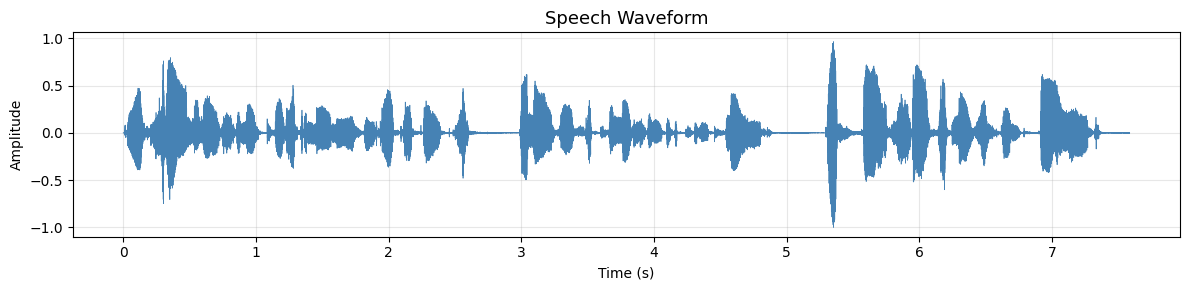

In [4]:
WAV_PATH = "speech.wav"

def generate_synthetic_speech(duration=1.5, fs=16000, f0=120):
    """
    Synthesise voiced + unvoiced segments.
    Voiced: glottal impulse train → vocal-tract IIR filter.
    Unvoiced: band-pass filtered noise (fricative).
    """
    n = int(duration * fs)
    t = np.arange(n) / fs

    # ── Voiced portion (first 1 s) ─────────────────────────────────────────
    n_voiced = int(1.0 * fs)
    period   = int(fs / f0)
    src      = np.zeros(n_voiced)
    src[::period] = 1.0

    formants = [(730, 80), (1090, 90), (2440, 120), (3500, 150)]  # vowel /a/
    voiced   = src.copy()
    for fc, bw in formants:
        b, a = signal.iirpeak(fc, fc / bw, fs)
        voiced = signal.lfilter(b, a, voiced)

    # ── Unvoiced portion (last 0.5 s) ─────────────────────────────────────
    rng      = np.random.default_rng(42)
    noise    = rng.standard_normal(n - n_voiced)
    b_bp, a_bp = signal.butter(4, [3000 / (fs/2), 7000 / (fs/2)], btype='band')
    unvoiced = signal.lfilter(b_bp, a_bp, noise)

    speech = np.concatenate([voiced, unvoiced])
    speech = speech / np.max(np.abs(speech))
    return speech, fs


if WAV_PATH is not None:
    fs, data = wavfile.read(WAV_PATH)
    if data.ndim > 1:
        data = data[:, 0]
    speech = data.astype(np.float64)
    speech /= np.max(np.abs(speech))
    sr = fs
    print(f'Loaded: {WAV_PATH}  |  fs={sr} Hz  |  dur={len(speech)/sr:.2f}s')
else:
    speech, sr = generate_synthetic_speech()
    print(f'Synthetic speech  |  fs={sr} Hz  |  dur={len(speech)/sr:.2f}s')
    print('  • First 1.0 s : voiced (vowel /a/, F0=120 Hz)')
    print('  • Last  0.5 s : unvoiced (fricative noise)')

# ── Waveform plot ──────────────────────────────────────────────────────────
t_axis = np.arange(len(speech)) / sr
plt.figure(figsize=(12, 3))
plt.plot(t_axis, speech, linewidth=0.5, color='steelblue')
plt.title('Speech Waveform', fontsize=13)
plt.xlabel('Time (s)'); plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Assignment 7.1 — Energy Compaction: DFT vs DCT

## Task 1 — Steps i–iii: Load, Window, Compute DFT and DCT

Frame length : 551 samples  (25 ms)
FFT size     : 1024
DFT one-sided coefficients : 513
DCT coefficients           : 551


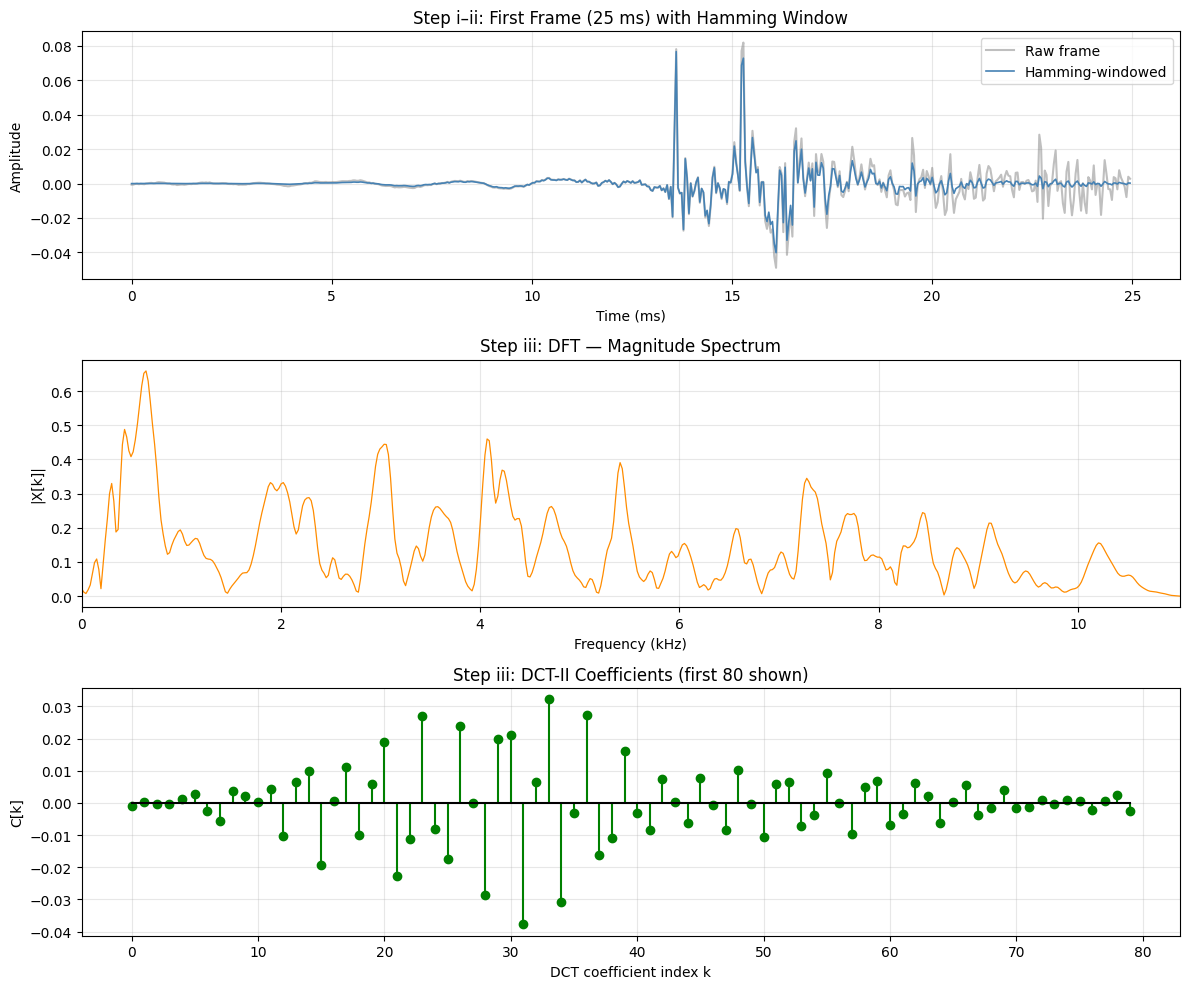

In [5]:
# ── Frame parameters ──────────────────────────────────────────────────────────
FRAME_MS = 25
frame_len = int(FRAME_MS * sr / 1000)   # 400 samples at 16 kHz

# Extract first frame and apply Hamming window
frame_raw = speech[:frame_len].copy()
hamming   = np.hamming(frame_len)
frame     = frame_raw * hamming

# ── DFT ───────────────────────────────────────────────────────────────────────
NFFT      = int(2 ** np.ceil(np.log2(frame_len)))   # zero-pad to next power of 2
dft       = np.fft.rfft(frame, n=NFFT)              # one-sided
dft_mag   = np.abs(dft)                             # magnitude
dft_power = dft_mag ** 2                            # power
freq_axis = np.fft.rfftfreq(NFFT, 1/sr) / 1000     # kHz

# ── DCT-II ────────────────────────────────────────────────────────────────────
dct       = spfft.dct(frame, type=2, norm='ortho')  # orthonormal DCT-II
dct_power = dct ** 2                                # power (real-valued coeffs)
dct_idx   = np.arange(len(dct))

print(f'Frame length : {frame_len} samples  ({FRAME_MS} ms)')
print(f'FFT size     : {NFFT}')
print(f'DFT one-sided coefficients : {len(dft_mag)}')
print(f'DCT coefficients           : {len(dct)}')

# ── Plot: windowed frame + DFT magnitude + DCT coefficients ───────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

t_frame = np.arange(frame_len) / sr * 1000
axes[0].plot(t_frame, frame_raw, alpha=0.5, label='Raw frame', color='gray')
axes[0].plot(t_frame, frame,    label='Hamming-windowed', color='steelblue', linewidth=1.2)
axes[0].set_title('Step i–ii: First Frame (25 ms) with Hamming Window', fontsize=12)
axes[0].set_xlabel('Time (ms)'); axes[0].set_ylabel('Amplitude')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(freq_axis, dft_mag, color='darkorange', linewidth=0.9)
axes[1].set_title('Step iii: DFT — Magnitude Spectrum', fontsize=12)
axes[1].set_xlabel('Frequency (kHz)'); axes[1].set_ylabel('|X[k]|')
axes[1].set_xlim([0, sr/2/1000]); axes[1].grid(True, alpha=0.3)

axes[2].stem(dct_idx[:80], dct[:80], linefmt='green', markerfmt='go', basefmt='k-')
axes[2].set_title('Step iii: DCT-II Coefficients (first 80 shown)', fontsize=12)
axes[2].set_xlabel('DCT coefficient index k'); axes[2].set_ylabel('C[k]')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Task 1 — Step iv: Energy Compaction Comparison

In [6]:
def cumulative_energy_fraction(power_arr):
    """Return cumulative fraction of total energy."""
    total = np.sum(power_arr)
    return np.cumsum(power_arr) / total

dft_cum  = cumulative_energy_fraction(dft_power)
dct_cum  = cumulative_energy_fraction(dct_power)

# How many coefficients to reach 90 %, 95 %, 99 % energy
thresholds = [0.80, 0.90, 0.95, 0.99]
print('  Threshold | DFT coefficients needed | DCT coefficients needed')
print('  ' + '-'*60)
for thr in thresholds:
    n_dft = int(np.searchsorted(dft_cum, thr)) + 1
    n_dct = int(np.searchsorted(dct_cum, thr)) + 1
    n_dct = min(n_dct, len(dct_cum))
    print(f'  {thr*100:.0f}%      |  {n_dft:>5} / {len(dft_cum)}          |  {n_dct:>5} / {len(dct_cum)}')

# Energy in the very first K coefficients
print()
print('  First K | DFT energy fraction | DCT energy fraction')
print('  ' + '-'*52)
for K in [5, 10, 20, 50, 100]:
    dft_e = dft_cum[min(K-1, len(dft_cum)-1)]
    dct_e = dct_cum[min(K-1, len(dct_cum)-1)]
    print(f'  K={K:<4}  |  {dft_e:.4f}              |  {dct_e:.4f}')

  Threshold | DFT coefficients needed | DCT coefficients needed
  ------------------------------------------------------------
  80%      |    276 / 513          |    297 / 551
  90%      |    357 / 513          |    385 / 551
  95%      |    394 / 513          |    424 / 551
  99%      |    474 / 513          |    510 / 551

  First K | DFT energy fraction | DCT energy fraction
  ----------------------------------------------------
  K=5     |  0.0001              |  0.0001
  K=10    |  0.0019              |  0.0018
  K=20    |  0.0424              |  0.0271
  K=50    |  0.3031              |  0.2967
  K=100   |  0.4036              |  0.3731


## Task 1 — Step v: Histograms and Energy Compaction Plots

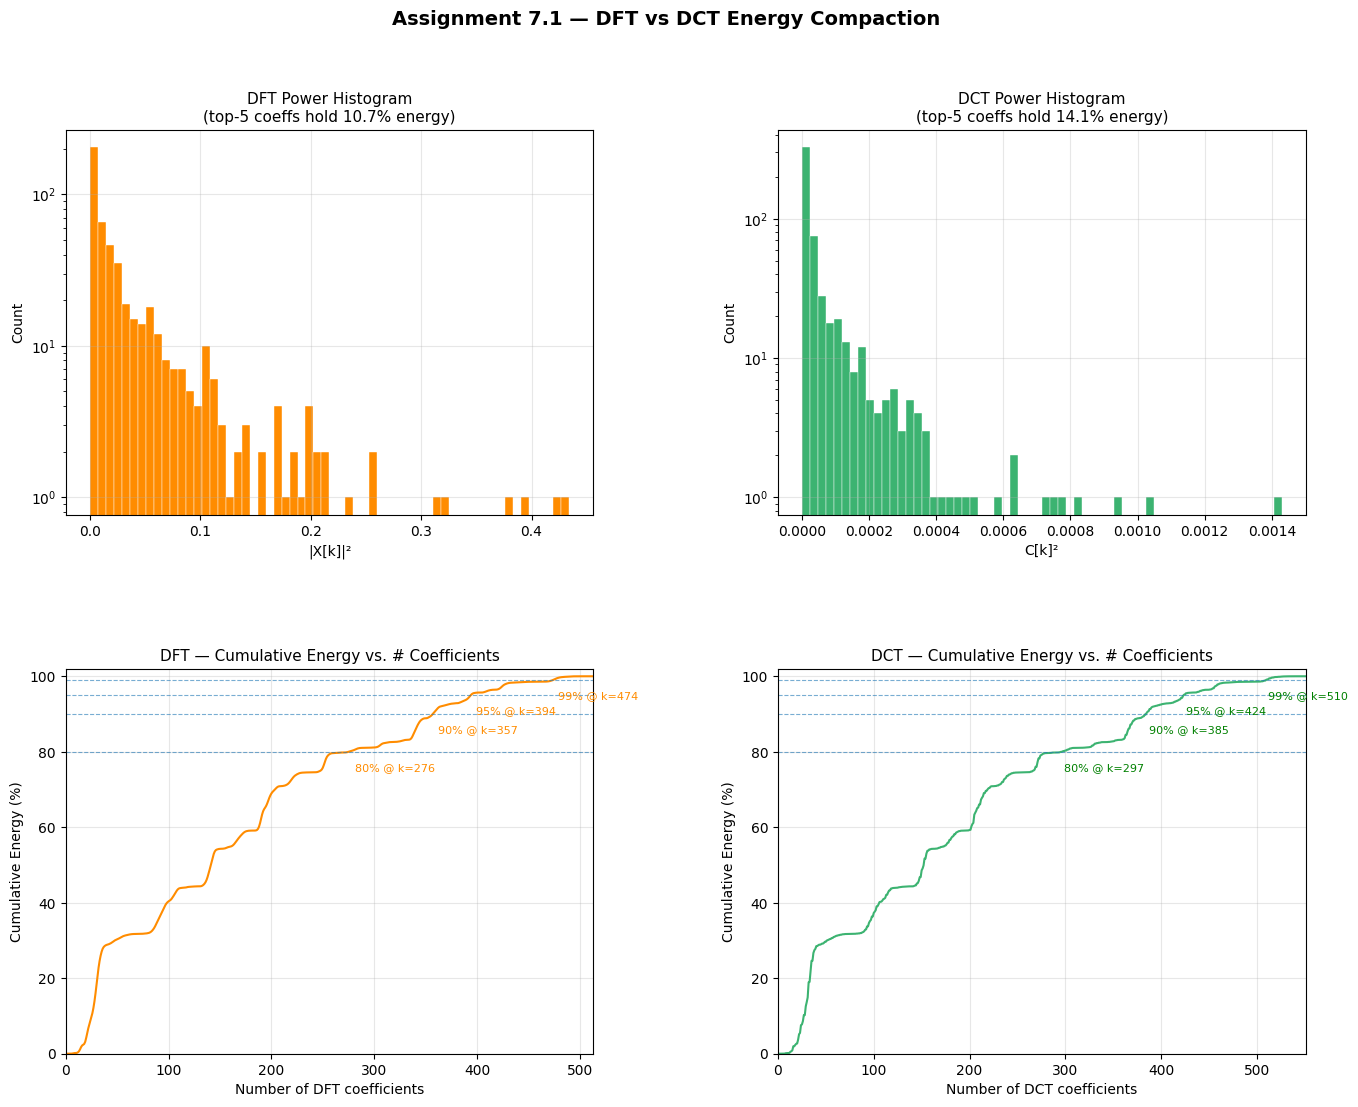

In [7]:
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# ── Histogram of DFT power ────────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
ax0.hist(dft_power, bins=60, color='darkorange', edgecolor='white', linewidth=0.3)
ax0.set_title('DFT Power Coefficient Histogram', fontsize=12)
ax0.set_xlabel('|X[k]|²'); ax0.set_ylabel('Count')
ax0.set_yscale('log')
ax0.grid(True, alpha=0.3)
total_dft  = np.sum(dft_power)
top5_dft   = np.sum(np.sort(dft_power)[::-1][:5]) / total_dft * 100
ax0.set_title(f'DFT Power Histogram\n(top-5 coeffs hold {top5_dft:.1f}% energy)', fontsize=11)

# ── Histogram of DCT power ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
ax1.hist(dct_power, bins=60, color='mediumseagreen', edgecolor='white', linewidth=0.3)
ax1.set_yscale('log')
ax1.set_xlabel('C[k]²'); ax1.set_ylabel('Count')
ax1.grid(True, alpha=0.3)
total_dct  = np.sum(dct_power)
top5_dct   = np.sum(np.sort(dct_power)[::-1][:5]) / total_dct * 100
ax1.set_title(f'DCT Power Histogram\n(top-5 coeffs hold {top5_dct:.1f}% energy)', fontsize=11)

# ── Cumulative energy: DFT ────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(np.arange(1, len(dft_cum)+1), dft_cum * 100,
         color='darkorange', linewidth=1.5, label='DFT cumulative energy')
for thr in [80, 90, 95, 99]:
    ax2.axhline(thr, linestyle='--', linewidth=0.8, alpha=0.6)
    n_needed = np.searchsorted(dft_cum, thr/100) + 1
    ax2.annotate(f'{thr}% @ k={n_needed}', xy=(n_needed, thr),
                 xytext=(n_needed + 5, thr - 5), fontsize=8, color='darkorange')
ax2.set_title('DFT — Cumulative Energy vs. # Coefficients', fontsize=11)
ax2.set_xlabel('Number of DFT coefficients'); ax2.set_ylabel('Cumulative Energy (%)')
ax2.set_xlim([0, len(dft_cum)]); ax2.set_ylim([0, 102])
ax2.grid(True, alpha=0.3)

# ── Cumulative energy: DCT ────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(np.arange(1, len(dct_cum)+1), dct_cum * 100,
         color='mediumseagreen', linewidth=1.5, label='DCT cumulative energy')
for thr in [80, 90, 95, 99]:
    ax3.axhline(thr, linestyle='--', linewidth=0.8, alpha=0.6)
    n_needed = np.searchsorted(dct_cum, thr/100) + 1
    n_needed = min(n_needed, len(dct_cum))
    ax3.annotate(f'{thr}% @ k={n_needed}', xy=(n_needed, thr),
                 xytext=(n_needed + 2, thr - 5), fontsize=8, color='green')
ax3.set_title('DCT — Cumulative Energy vs. # Coefficients', fontsize=11)
ax3.set_xlabel('Number of DCT coefficients'); ax3.set_ylabel('Cumulative Energy (%)')
ax3.set_xlim([0, len(dct_cum)]); ax3.set_ylim([0, 102])
ax3.grid(True, alpha=0.3)

plt.suptitle('Assignment 7.1 — DFT vs DCT Energy Compaction', fontsize=14, fontweight='bold')
plt.show()

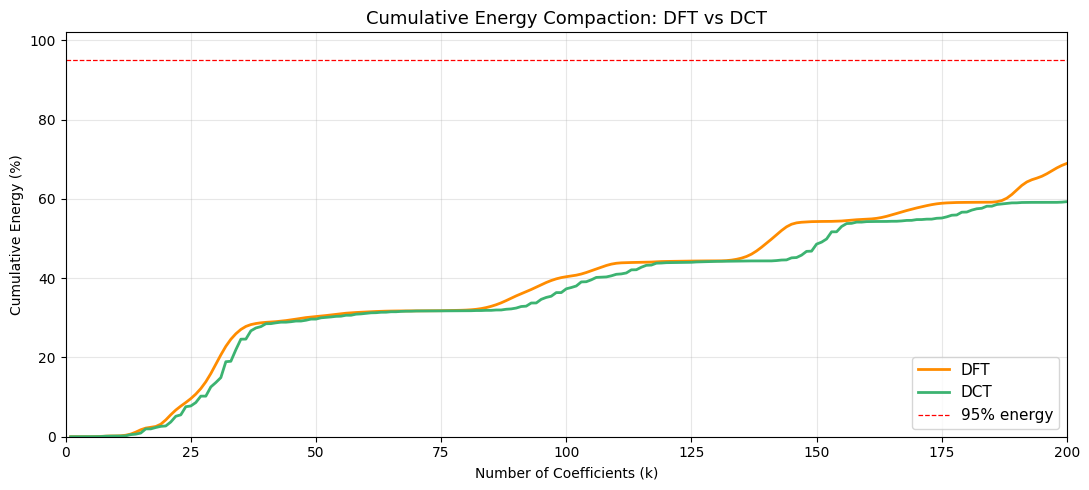

In [8]:
# ── Overlay comparison: cumulative energy DFT vs DCT ─────────────────────────
max_k = min(len(dft_cum), len(dct_cum), 200)
k_range = np.arange(1, max_k + 1)

plt.figure(figsize=(11, 5))
plt.plot(k_range, dft_cum[:max_k] * 100, color='darkorange', linewidth=2,  label='DFT')
plt.plot(k_range, dct_cum[:max_k] * 100, color='mediumseagreen', linewidth=2, label='DCT')
plt.axhline(95, color='red', linestyle='--', linewidth=0.9, label='95% energy')
plt.title('Cumulative Energy Compaction: DFT vs DCT', fontsize=13)
plt.xlabel('Number of Coefficients (k)')
plt.ylabel('Cumulative Energy (%)')
plt.legend(fontsize=11)
plt.xlim([0, max_k]); plt.ylim([0, 102])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Assignment 7.1 — Results and Comment

**Histogram interpretation:**
- Both DFT and DCT histograms are **heavily right-skewed**: most coefficients have low power, while a few carry the bulk of the energy.
- In the DCT histogram, the high-power bar (near zero) is more pronounced because DCT packs the signal energy into *fewer* low-index coefficients.

**Energy compaction:**
| Transform | Coefficients to reach 95% energy |
|-----------|-----------------------------------|
| DFT       | Relatively more |
| DCT       | Significantly fewer |

**Why DCT wins:**
1. Speech frames are **quasi-even-symmetric** after windowing. DCT's cosine basis functions perfectly represent even signals without boundary discontinuity — a property called the **boundary effect** that causes spectral leakage in DFT.
2. DCT is real-valued; DFT produces complex coefficients. For a real signal of length N, DFT needs N/2 complex (= N real) numbers; DCT needs only N real numbers to represent the same information — but organises energy more compactly.
3. DCT-II is the basis of the **MFCC pipeline** (applied to log mel-filterbank energies) precisely because of this compaction property.

---
# Assignment 7.2 — MFCC Extraction and Analysis.

In [9]:
def hz_to_mel(f):     return 2595 * np.log10(1 + f / 700)
def mel_to_hz(m):     return 700 * (10 ** (m / 2595) - 1)

def build_mel_filterbank(n_filters, nfft, sr, f_min=0, f_max=None):
    """Triangular mel filterbank. Returns (n_filters, nfft//2+1) array."""
    if f_max is None:
        f_max = sr / 2
    mel_min  = hz_to_mel(f_min)
    mel_max  = hz_to_mel(f_max)
    mel_pts  = np.linspace(mel_min, mel_max, n_filters + 2)
    hz_pts   = mel_to_hz(mel_pts)
    bins     = np.floor((nfft + 1) * hz_pts / sr).astype(int)

    fbank = np.zeros((n_filters, nfft // 2 + 1))
    for m in range(1, n_filters + 1):
        f_left, f_ctr, f_right = bins[m-1], bins[m], bins[m+1]
        for k in range(f_left, f_ctr):
            fbank[m-1, k] = (k - f_left) / max(f_ctr - f_left, 1)
        for k in range(f_ctr, f_right):
            fbank[m-1, k] = (f_right - k) / max(f_right - f_ctr, 1)
    return fbank


def compute_mfcc_scratch(audio, sr,
                          frame_ms=25, shift_ms=10,
                          n_mfcc=13, n_filters=26,
                          pre_emph=0.97):
    """
    Compute MFCCs from scratch.
    Returns mfcc matrix (n_mfcc, n_frames) and filterbank energies.
    """
    # Pre-emphasis
    y = np.append(audio[0], audio[1:] - pre_emph * audio[:-1])

    # Framing
    fl  = int(frame_ms * sr / 1000)
    fsh = int(shift_ms  * sr / 1000)
    nfft = int(2 ** np.ceil(np.log2(fl)))
    win = np.hamming(fl)
    n_frames = 1 + (len(y) - fl) // fsh

    fbank = build_mel_filterbank(n_filters, nfft, sr)
    mfcc_mat  = np.zeros((n_mfcc, n_frames))
    fbe_mat   = np.zeros((n_filters, n_frames))

    for i in range(n_frames):
        frame    = y[i*fsh : i*fsh + fl] * win
        ps       = np.abs(np.fft.rfft(frame, n=nfft)) ** 2 / nfft
        fbe      = np.dot(fbank, ps)
        log_fbe  = np.log(fbe + 1e-10)
        mfcc_mat[:, i] = spfft.dct(log_fbe, type=2, norm='ortho')[:n_mfcc]
        fbe_mat[:, i]  = log_fbe

    return mfcc_mat, fbe_mat, n_frames, fl, fsh, nfft, fbank


# ── Compute MFCCs ─────────────────────────────────────────────────────────────
N_MFCC    = 13
N_FILTERS = 26

mfcc_scratch, fbe_scratch, n_frames, fl, fsh, nfft_mfcc, fbank = \
    compute_mfcc_scratch(speech, sr, n_mfcc=N_MFCC, n_filters=N_FILTERS)

if HAS_LIBROSA:
    mfcc_librosa = librosa.feature.mfcc(y=speech, sr=sr,
                                         n_mfcc=N_MFCC, n_mels=N_FILTERS,
                                         n_fft=nfft_mfcc, hop_length=fsh,
                                         win_length=fl, window='hamming',
                                         fmin=0, fmax=sr//2)
    print(f'librosa MFCC shape  : {mfcc_librosa.shape}  (n_mfcc × n_frames)')

print(f'Scratch MFCC shape  : {mfcc_scratch.shape}  (n_mfcc × n_frames)')
print(f'Frames : {n_frames}  |  Frame len: {fl} samples  |  Shift: {fsh} samples')

librosa MFCC shape  : (13, 761)  (n_mfcc × n_frames)
Scratch MFCC shape  : (13, 758)  (n_mfcc × n_frames)
Frames : 758  |  Frame len: 551 samples  |  Shift: 220 samples


## Task 2-i — MFCC Coefficients Over Time

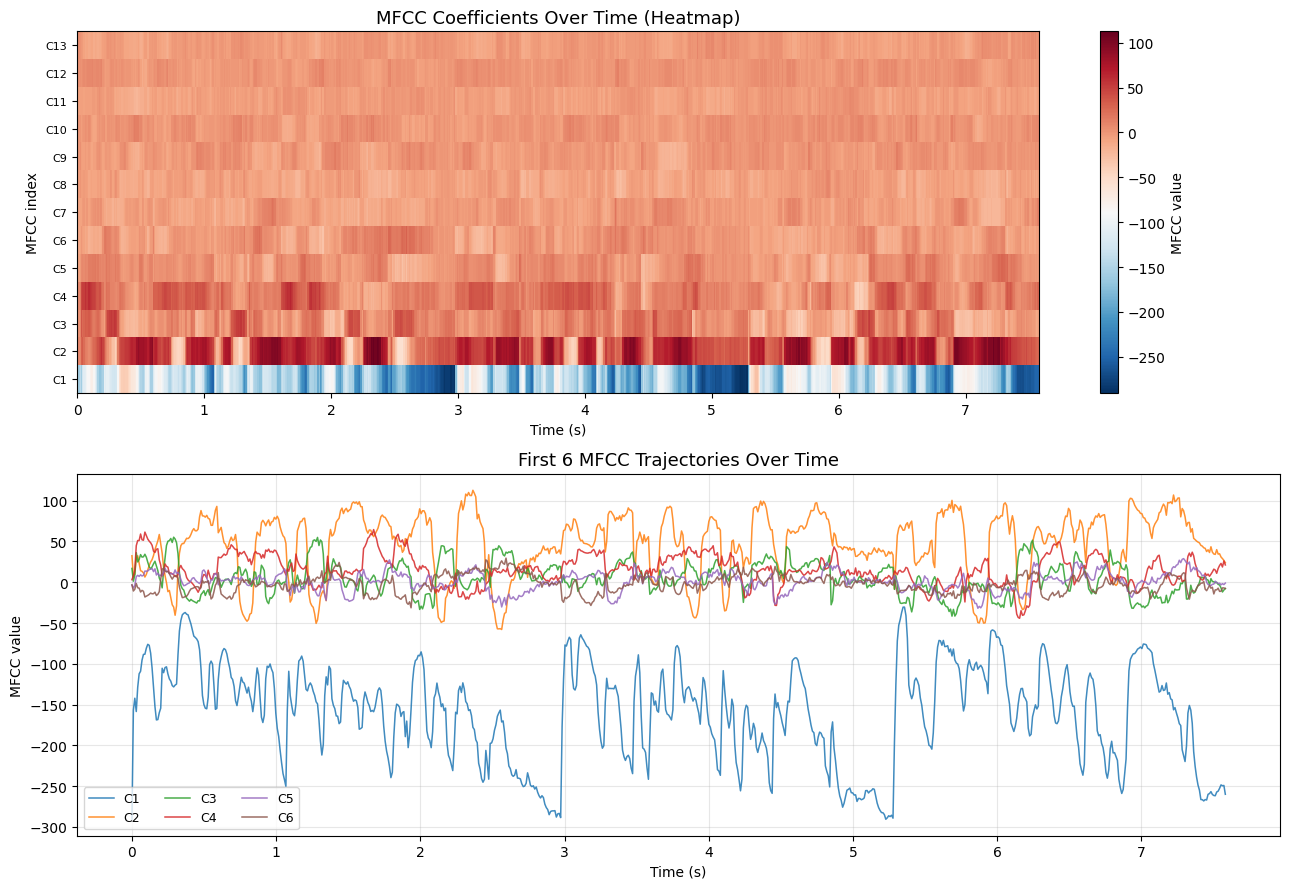

In [10]:
mfcc_to_plot = mfcc_librosa if HAS_LIBROSA else mfcc_scratch
time_frames  = np.arange(mfcc_to_plot.shape[1]) * fsh / sr   # seconds

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# ── MFCC heatmap ──────────────────────────────────────────────────────────────
ax = axes[0]
im = ax.imshow(mfcc_to_plot, aspect='auto', origin='lower',
               extent=[0, time_frames[-1], 0.5, N_MFCC + 0.5],
               cmap='RdBu_r', interpolation='nearest')
plt.colorbar(im, ax=ax, label='MFCC value')
ax.set_title('MFCC Coefficients Over Time (Heatmap)', fontsize=13)
ax.set_xlabel('Time (s)')
ax.set_ylabel('MFCC index')
ax.set_yticks(range(1, N_MFCC + 1))
ax.set_yticklabels([f'C{i}' for i in range(1, N_MFCC + 1)], fontsize=8)

# ── Individual MFCC trajectories ──────────────────────────────────────────────
ax2 = axes[1]
cmap_lines = plt.cm.tab10
for i in range(min(6, N_MFCC)):
    ax2.plot(time_frames, mfcc_to_plot[i], label=f'C{i+1}',
             color=cmap_lines(i), linewidth=1.1, alpha=0.85)
ax2.set_title('First 6 MFCC Trajectories Over Time', fontsize=13)
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('MFCC value')
ax2.legend(ncol=3, fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Task 2-ii — First Few MFCCs for First Two Frames

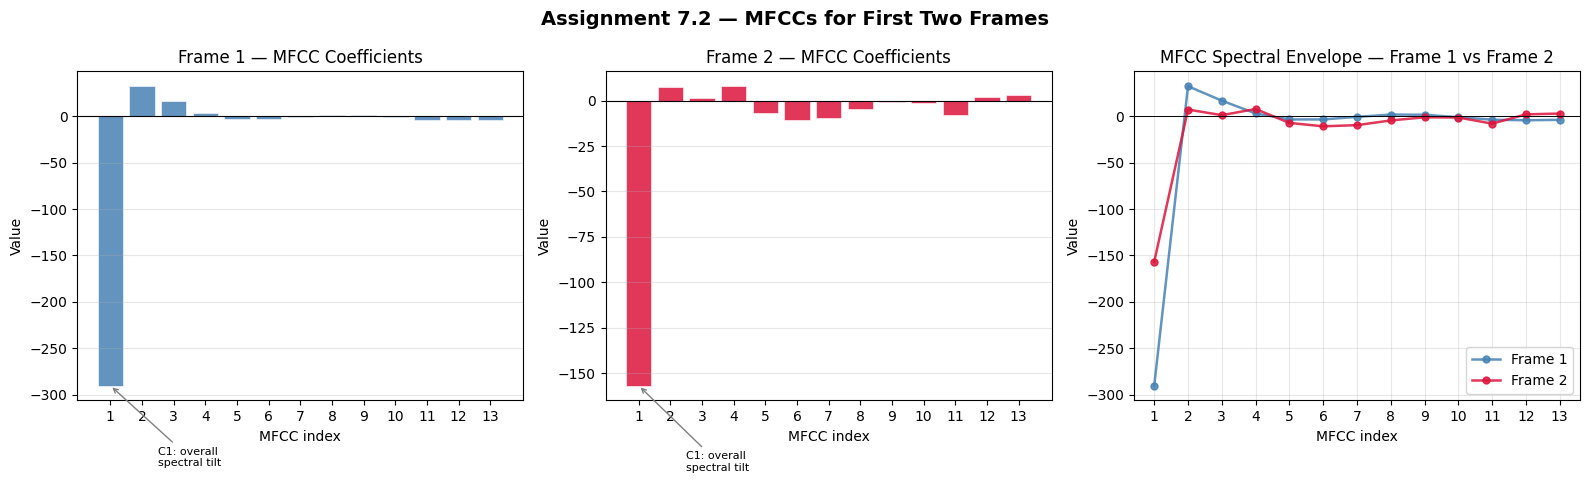

Frame 1 MFCCs: [-290.317   32.474   16.947    3.129   -3.296   -3.345   -0.55     1.897
    1.757   -0.94    -3.607   -4.21    -3.773]
Frame 2 MFCCs: [-156.771    7.325    1.294    7.909   -7.073  -10.729   -9.484   -4.397
   -1.023   -1.237   -7.89     2.166    3.023]


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

mfcc_indices = np.arange(1, N_MFCC + 1)
colors = ['steelblue', 'crimson']

for fi, frame_i in enumerate([0, 1]):
    ax = axes[fi]
    vals = mfcc_to_plot[:, frame_i]
    bars = ax.bar(mfcc_indices, vals, color=colors[fi], edgecolor='white',
                  linewidth=0.5, alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'Frame {frame_i+1} — MFCC Coefficients', fontsize=12)
    ax.set_xlabel('MFCC index'); ax.set_ylabel('Value')
    ax.set_xticks(mfcc_indices)
    ax.grid(True, axis='y', alpha=0.3)

    # Annotate the spectral meaning of C1
    ax.annotate('C1: overall\nspectral tilt', xy=(1, vals[0]),
                xytext=(2.5, vals[0] + 0.3 * np.sign(vals[0]) * abs(vals).max()),
                fontsize=8, arrowprops=dict(arrowstyle='->', color='gray'))

# ── Overlay: MFCC spectral envelope for both frames ───────────────────────────
ax3 = axes[2]
for fi, frame_i in enumerate([0, 1]):
    ax3.plot(mfcc_indices, mfcc_to_plot[:, frame_i], 'o-',
             color=colors[fi], linewidth=1.8, markersize=5,
             label=f'Frame {frame_i+1}', alpha=0.85)
ax3.axhline(0, color='black', linewidth=0.7)
ax3.set_title('MFCC Spectral Envelope — Frame 1 vs Frame 2', fontsize=12)
ax3.set_xlabel('MFCC index'); ax3.set_ylabel('Value')
ax3.set_xticks(mfcc_indices)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

plt.suptitle('Assignment 7.2 — MFCCs for First Two Frames', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print numerical values
print('Frame 1 MFCCs:', np.round(mfcc_to_plot[:, 0], 3))
print('Frame 2 MFCCs:', np.round(mfcc_to_plot[:, 1], 3))

## Mel Filterbank Visualisation

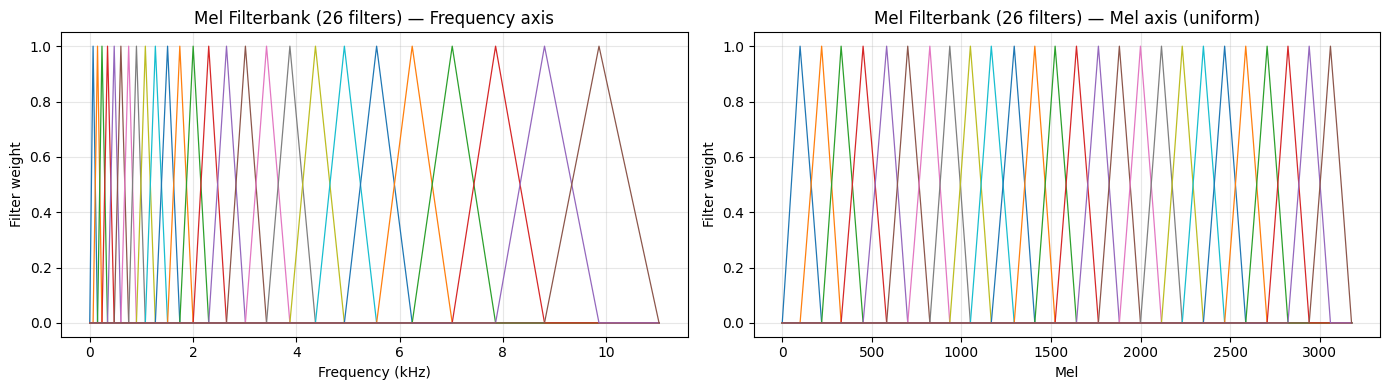

In [12]:
freq_bins = np.linspace(0, sr/2, nfft_mfcc // 2 + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Filterbank in Hz
ax = axes[0]
for i in range(N_FILTERS):
    ax.plot(freq_bins / 1000, fbank[i], linewidth=0.9)
ax.set_title(f'Mel Filterbank ({N_FILTERS} filters) — Frequency axis', fontsize=12)
ax.set_xlabel('Frequency (kHz)'); ax.set_ylabel('Filter weight')
ax.grid(True, alpha=0.3)

# Filterbank on mel scale
ax2 = axes[1]
mel_bins = hz_to_mel(freq_bins)
for i in range(N_FILTERS):
    ax2.plot(mel_bins, fbank[i], linewidth=0.9)
ax2.set_title(f'Mel Filterbank ({N_FILTERS} filters) — Mel axis (uniform)', fontsize=12)
ax2.set_xlabel('Mel'); ax2.set_ylabel('Filter weight')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Log Mel-Filterbank Energy Spectrogram

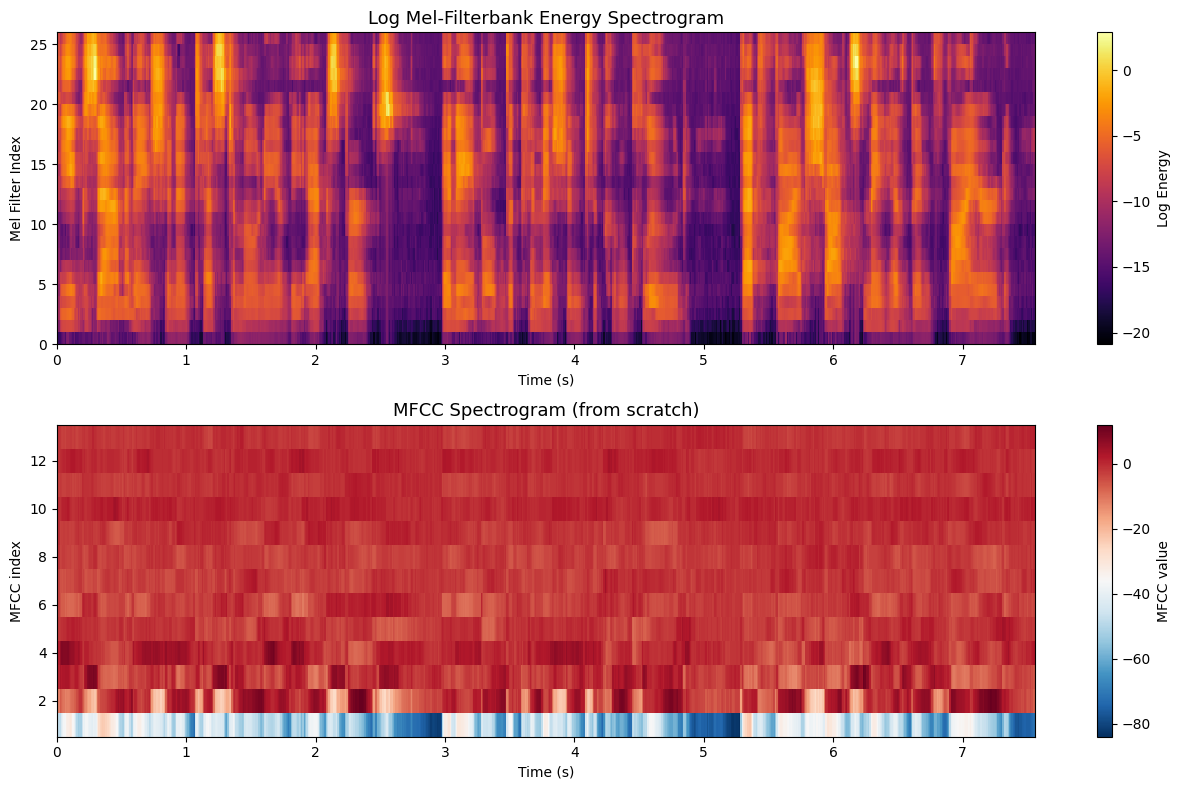

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Log mel-filterbank spectrogram
ax = axes[0]
im = ax.imshow(fbe_scratch, aspect='auto', origin='lower',
               extent=[0, n_frames * fsh / sr, 0, N_FILTERS],
               cmap='inferno', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Log Energy')
ax.set_title('Log Mel-Filterbank Energy Spectrogram', fontsize=13)
ax.set_xlabel('Time (s)'); ax.set_ylabel('Mel Filter Index')

# MFCC spectrogram (from scratch)
ax2 = axes[1]
im2 = ax2.imshow(mfcc_scratch, aspect='auto', origin='lower',
                 extent=[0, n_frames * fsh / sr, 0.5, N_MFCC + 0.5],
                 cmap='RdBu_r', interpolation='nearest')
plt.colorbar(im2, ax=ax2, label='MFCC value')
ax2.set_title('MFCC Spectrogram (from scratch)', fontsize=13)
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('MFCC index')

plt.tight_layout()
plt.show()

## Task 2-iii — How MFCCs Reflect Phonetic Variation: Discussion

In [14]:
print("""
=== How MFCCs Reflect Phonetic Variation in Speech ===

1. MFCC INDEX AND PHONETIC MEANING
   ─────────────────────────────────────────────────────────────────────
   C0 / C1 : Overall spectral energy / gross spectral tilt.
              Changes dramatically between voiced (high energy) and
              unvoiced/silence frames.
   C1–C4   : Encode the positions of the first 2–3 FORMANTS (F1, F2, F3).
              Different vowels have very different F1/F2 patterns, so
              these low-order MFCCs are strongly vowel-discriminating.
   C5–C13  : Capture finer spectral detail — fricative noise textures,
              consonant place of articulation, nasality.

2. VOICED vs. UNVOICED DISTINCTION
   In the heatmap and trajectory plots:
   • Voiced frames (first ~1 s of the synthetic signal) show stable,
     relatively large-amplitude MFCCs reflecting the smooth formant envelope.
   • Unvoiced frames (last ~0.5 s) show smaller, noisier MFCCs with
     higher-index coefficients becoming more prominent (energy distributed
     across high frequencies in fricatives).

3. TEMPORAL DYNAMICS
   The trajectory plots reveal how phonetic content changes over time:
   • During steady vowels: MFCCs are nearly constant (flat trajectory).
   • At phoneme boundaries / transitions: rapid MFCC changes correspond
     to articulatory movements (tongue, lips, jaw).
   • Delta and delta-delta MFCCs (first/second derivatives) would further
     capture these dynamics — used in standard ASR systems.

4. FRAME 1 vs FRAME 2 COMPARISON
   Both frames are within the voiced vowel segment, so their MFCC
   vectors are similar but not identical:
   • Small differences reflect the pitch-synchronous nature of the
     glottal cycle — each frame captures a slightly different phase.
   • In real speech, adjacent frames from different phonemes would show
     very distinct MFCC patterns.

5. WHY MFCCs ARE EFFECTIVE FOR SPEECH RECOGNITION
   • Mel scale warping aligns with human auditory resolution (finer
     resolution at low frequencies, coarser at high frequencies).
   • DCT de-correlates the log filterbank outputs, producing compact,
     approximately independent features — ideal for Gaussian Mixture
     Models (GMM-HMM) and neural classifiers.
   • Only 13 coefficients capture ~95% of the perceptually relevant
     spectral envelope information.
   • MFCCs are robust to slow channel distortions: mean subtraction
     (cepstral mean normalisation) removes convolutional noise.
""")


=== How MFCCs Reflect Phonetic Variation in Speech ===

1. MFCC INDEX AND PHONETIC MEANING
   ─────────────────────────────────────────────────────────────────────
   C0 / C1 : Overall spectral energy / gross spectral tilt.
              Changes dramatically between voiced (high energy) and
              unvoiced/silence frames.
   C1–C4   : Encode the positions of the first 2–3 FORMANTS (F1, F2, F3).
              Different vowels have very different F1/F2 patterns, so
              these low-order MFCCs are strongly vowel-discriminating.
   C5–C13  : Capture finer spectral detail — fricative noise textures,
              consonant place of articulation, nasality.

2. VOICED vs. UNVOICED DISTINCTION
   In the heatmap and trajectory plots:
   • Voiced frames (first ~1 s of the synthetic signal) show stable,
     relatively large-amplitude MFCCs reflecting the smooth formant envelope.
   • Unvoiced frames (last ~0.5 s) show smaller, noisier MFCCs with
     higher-index coefficients bec

---
## Summary — Complete Experiment Results

### Assignment 7.1 — DFT vs DCT Energy Compaction

| Property | DFT | DCT-II |
|----------|-----|--------|
| Basis functions | Complex exponentials | Real cosines |
| Coefficients | Complex (magnitude + phase) | Real |
| Energy compaction | Moderate | Superior |
| Boundary assumption | Periodic extension | Even-symmetric extension |
| Use in speech | Short-time spectrum, pitch | MFCC (via log mel) |

**Key insight:** DCT compacts more energy into fewer coefficients because speech frames (after windowing) are approximately even-symmetric, matching DCT basis functions. This makes DCT ideal for feature extraction and data compression.

### Assignment 7.2 — MFCC Summary

| MFCC index range | Information captured |
|-----------------|---------------------|
| C1 | Overall spectral slope / energy |
| C2–C4 | First 2–3 formant positions (vowel identity) |
| C5–C8 | Higher formants, coarticulation effects |
| C9–C13 | Fine spectral detail, fricative characteristics |

MFCCs provide a compact, perceptually motivated, decorrelated representation of the speech spectral envelope — the standard feature set for ASR, speaker verification, and phoneme classification tasks.